In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# ============================================
# 1. DEFINE COLD REGIONS (from your simulation)
# ============================================
COLD_REGIONS = [
    'Normandie', 'Hauts-de-France', 'Grand Est', 
    'Bourgogne-Franche-Comté', 'Bretagne', 'Centre-Val de Loire'
]

# Load original clean quote data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])
print(f"\n📊 Original quote data: {len(df_quotes):,} quotes from {df_quotes['numero_compte'].nunique():,} customers")

# ============================================
# 2. FILTER TO COLD REGIONS ONLY
# ============================================
df_quotes_cold = df_quotes[df_quotes['nom_region'].isin(COLD_REGIONS)].copy()
print(f"\n❄️ COLD REGION CUSTOMERS ONLY:")
print(f"   Quotes: {len(df_quotes_cold):,} ({len(df_quotes_cold)/len(df_quotes)*100:.1f}% of total)")
print(f"   Customers: {df_quotes_cold['numero_compte'].nunique():,}")


📊 Original quote data: 37,008 quotes from 25,716 customers

❄️ COLD REGION CUSTOMERS ONLY:
   Quotes: 20,964 (56.6% of total)
   Customers: 14,639



📊 Original quote data: 20,964 quotes from 14,639 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 14,639, Quotes: 20,309
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 14,639 customers | 41.0% converters
⏱️  Execution time: 6.1 seconds
⚠️  6.1s (target was 3s)
CREATING SEQUENCE FEATURES (mode: first_conversion)
  Total quotes: 20,964
  Total customers: 14,639
  Using product column: regroup_famille_equipement_produit_principal
  Window days: 30
  Filtering post-first-purchase data...
    Customers after filter: 14,639
    Quotes after filter: 20,347
⚡ Processing 14,639 customers with sequence features...
  Processed 5,000/14,639 customers
  Processed 10,000/14,639 customers

  Adding categorical features...

✅ SEQUENCE FEATURES CREATED
  Total customers: 14,639
  Converters: 6,003 (41.0%)
  Featu

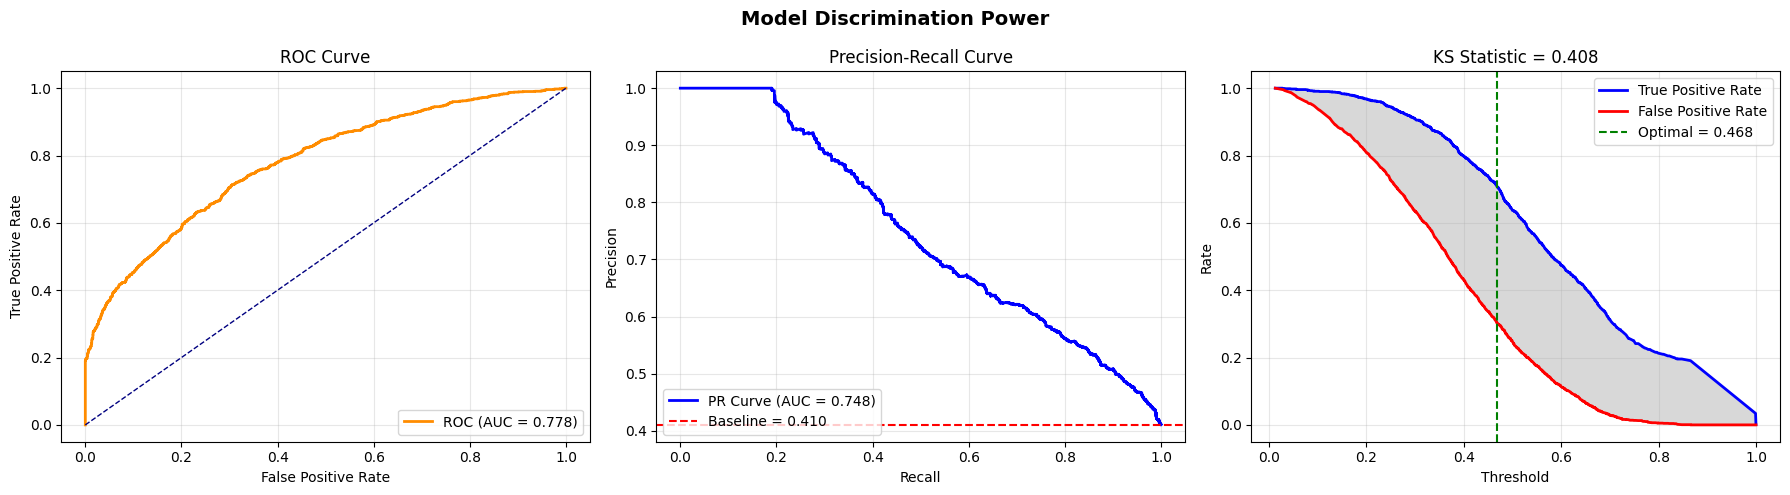

• ROC-AUC: 0.7784
• PR-AUC: 0.7476
• KS Statistic: 0.408 (GOOD discrimination)
• Optimal Threshold: 0.468

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.953
Decile 10 mean prob: 0.109


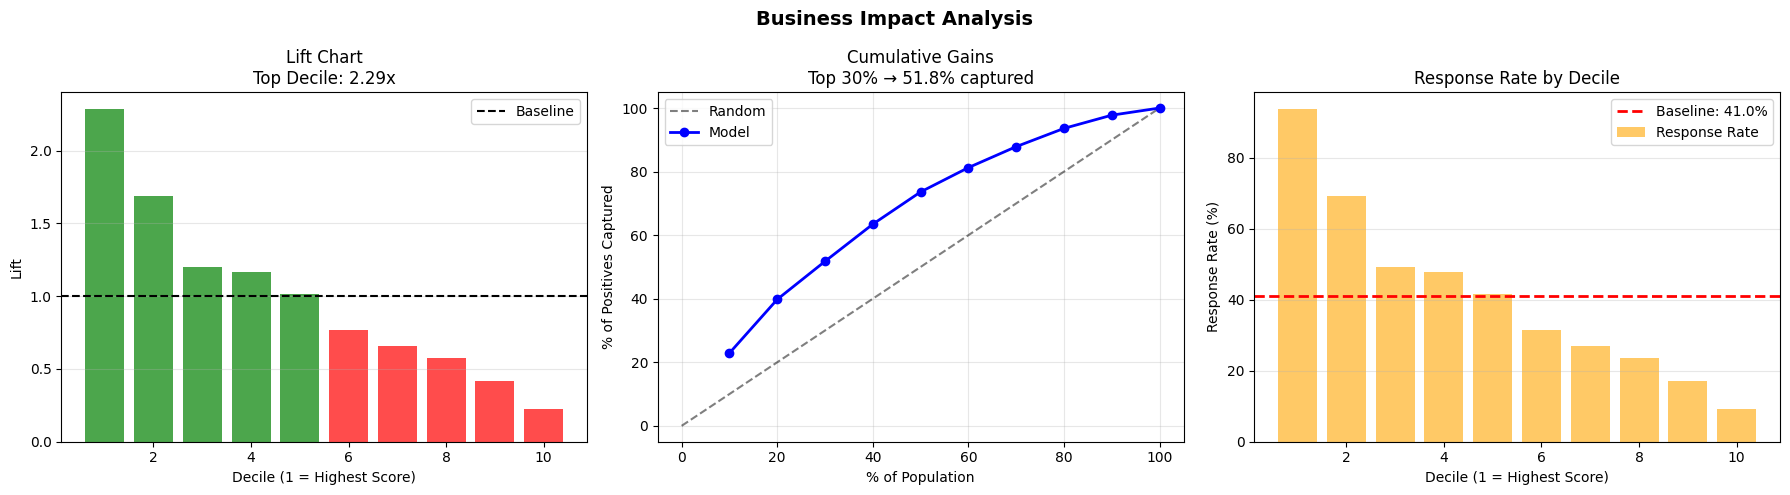

• Top Decile Lift: 0.22x
• Top 30% captures: 51.8% of positives
• Baseline response rate: 41.0%
• Top decile response: 93.9%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


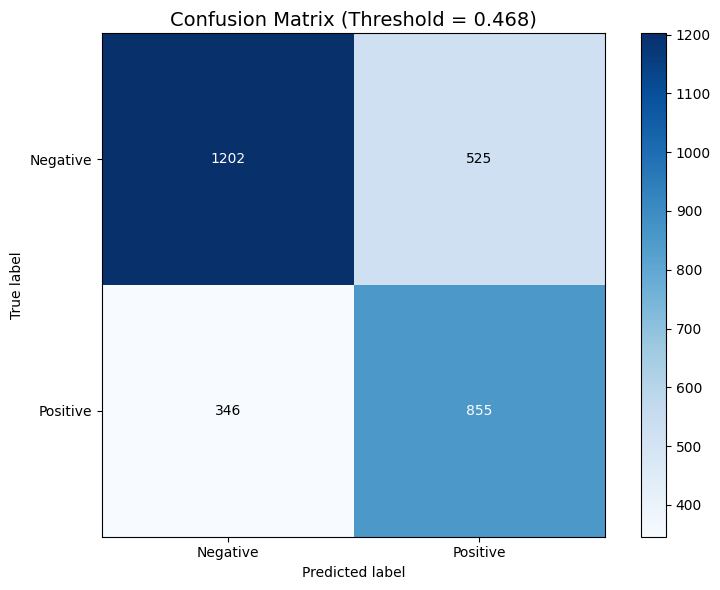

At threshold 0.468:
• Accuracy: 0.703
• Precision: 0.620
• Recall: 0.712
• F1-Score: 0.663
• True Positives: 855
• False Positives: 525
• True Negatives: 1202
• False Negatives: 346

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.408 (GOOD discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.22x better than random
   Coverage: Top 30% → 51.8% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.7784 (Excellent if >0.8)
   PR-AUC: 0.7476 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.468
   Precision at threshold: 0.620
   Recall at threshold: 0.712

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                                    feature  importance
178                 quote_consistency_score    0.105090
167                        is_quick_decider    0.055528
213            engagement_consistency_score    0.037623
214                  speed_complexity_ratio    0.032303
155                      engagement_density    0.027526
250              

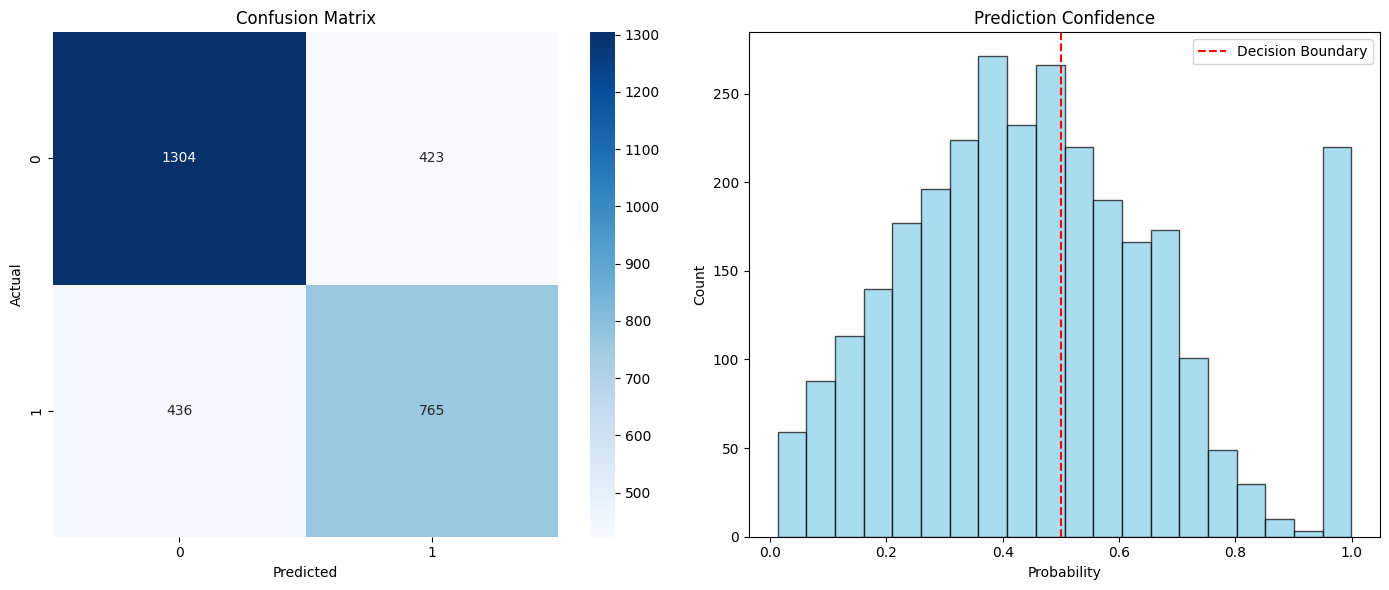

In [3]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes_cold)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])